In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_global_repository"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [16]:
steps=[
    "open_search", 
    "neutral_loss_search",
    "hybrid_search"
    ]


query_size=100
# query_size=10
ion_mode=[-1,1]



In [17]:
df=[]
for charge in ion_mode:
    for i in range(query_size):
        data={"query_idx":i, "charge":charge}
        
        for step in steps:       
            
            
            path_benchmark_repository=path_benchmark_data/f"repository_{charge}_repository_memory_usage_{step}_step_query_{i}.txt"
            



            with open(path_benchmark_repository,"r") as f:
                for line in f.readlines():
                    items=line.split(":", maxsplit=1)
                    key, value=items
                    if key.strip()=="Maximum resident set size (kbytes)":
                        repository=int(value.strip())


            data["repository"]=repository/1048576
            data["search_type"]=step 


            df.append(pd.DataFrame([data]))
            
df=pd.concat(df)

df


,query_idx,charge,repository,search_type
0,0,-1,0.219395,open_search
0,0,-1,0.245975,neutral_loss_search
0,0,-1,0.374550,hybrid_search
0,1,-1,0.158638,open_search
0,1,-1,0.218765,neutral_loss_search
...,...,...,...,...
0,98,1,0.301300,neutral_loss_search
0,98,1,0.584126,hybrid_search
0,99,1,0.151764,open_search
0,99,1,0.153515,neutral_loss_search


In [18]:


df_data = df[["search_type", 
            "repository",
            "charge"]]    
        


In [19]:
color_palette={
    1: '#FCD470',
    -1:'#66BC98'
}


In [ ]:
def plot_memory_different_search_repository(
    df,
    color_palette,
    ylim,
    save_path
):
    df_charge=df[df["charge"]==charge]
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3, 2.4), width_ratios=[1,1,1], sharex=False, sharey=True)

    steps=['open_search','neutral_loss_search','hybrid_search']
    for idx, step in enumerate(steps):
        ax = axes[idx]
        subset = df[df['search_type'] == step]
        
        sns.boxplot(data=subset, x='charge', y='repository', ax=ax, hue='charge',palette=color_palette, linewidth=0.4, width=0.5, fliersize=0, legend=False)
        sns.stripplot(data=subset, x='charge', y='repository', ax=ax, hue='charge', palette=color_palette,dodge=False, jitter=0.25, size=1, alpha=0.5, linewidth=0, legend=False)
        ax.set_title(f'{step.replace("_"," ").title()}' , fontsize=matplotlib_font_size)
        ax.set_ylabel('Library Search Memory Usage (GB)' if idx == 0 else '')

        ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.3)
        for spine in ax.spines.values():  
            spine.set_linewidth(0.3)
        ax.tick_params(which="both", width=0.3) 
        bottom=ylim[0]
        top=ylim[1]
        ax.set_ylim(top=top,bottom=bottom)
        label_mapping = {
            -1: '(-) ESI',
            1: '(+) ESI'
        }
        # ax.set_yscale("log")
        ax.set_xlabel('')
        unique_charges = sorted(subset['charge'].unique(), key=lambda x: int(x))
        ax.set_xticks(range(len(unique_charges)))
        custom_labels = [label_mapping.get(int(charge), charge) for charge in unique_charges]
        ax.set_xticklabels(custom_labels)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    # Save figure
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)    

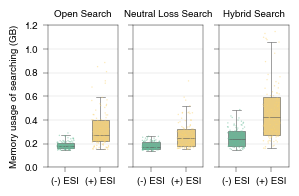

In [21]:
ylim=(0,1.2)
save_path=path_figures / f"compare_memory_different_search_methods_lib_scale_repository.svg"
plot_memory_different_search_repository(
    df=df,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)